# Time-Series Evaluation Summary Tables

Generates per-model summary tables (Mean CRPS, % R² ≥ 0.7) from `ts_evaluation_best_per_sample.csv` files.

In [1]:
import pandas as pd
import os
import glob
from IPython.display import display, HTML

TOOLKIT_ORDER = ["none", "static", "generate_only"]
DATASET_ORDER = ["easy_50", "chirp_50", "medium_110"]
EXPECTED_SAMPLES = {"easy_50": 50, "chirp_50": 50, "medium_110": 110}


def load_eval_folder(base_dir: str) -> pd.DataFrame:
    """Load all best-per-sample CSVs from an eval folder and return a summary DataFrame."""
    rows = []
    for path in sorted(glob.glob(f"{base_dir}/ts_*/ts_evaluation_best_per_sample.csv")):
        df = pd.read_csv(path)
        folder = os.path.basename(os.path.dirname(path))

        # Parse toolkit
        if "none" in folder:
            toolkit = "none"
        elif "static" in folder:
            toolkit = "static"
        elif "genonly" in folder:
            toolkit = "generate_only"
        else:
            toolkit = folder

        # Parse dataset
        if "easy_50" in folder:
            dataset = "easy_50"
        elif "chirp_50" in folder:
            dataset = "chirp_50"
        elif "medium_110" in folder:
            dataset = "medium_110"
        else:
            dataset = folder

        n_expected = EXPECTED_SAMPLES.get(dataset, len(df))
        n_valid = len(df)
        mean_crps = df["crps"].mean()
        n_r2_ge07 = int((df["r2"] >= 0.7).sum())
        pct_r2_ge07 = n_r2_ge07 / n_valid * 100

        rows.append({
            "toolkit": toolkit,
            "dataset": dataset,
            "n_expected": n_expected,
            "n_valid": n_valid,
            "mean_crps": mean_crps,
            "n_r2_ge07": n_r2_ge07,
            "pct_r2_ge07": pct_r2_ge07,
        })
    return pd.DataFrame(rows)


def make_crps_table(summary: pd.DataFrame) -> pd.DataFrame:
    tbl = summary.pivot(index="toolkit", columns="dataset", values="mean_crps")
    return tbl.reindex(columns=DATASET_ORDER, index=TOOLKIT_ORDER).round(4)


def make_r2_table(summary: pd.DataFrame) -> pd.DataFrame:
    summary = summary.copy()
    summary["r2_label"] = summary.apply(
        lambda r: f"{r['n_r2_ge07']}/{r['n_valid']} ({r['pct_r2_ge07']:.1f}%)", axis=1
    )
    tbl = summary.pivot(index="toolkit", columns="dataset", values="r2_label")
    return tbl.reindex(columns=DATASET_ORDER, index=TOOLKIT_ORDER)

## Claude (New Runs)

In [2]:
claude_summary = load_eval_folder("claude_ts_runs_eval_new")

print("Claude — Mean CRPS (lower is better)")
display(make_crps_table(claude_summary))

print("\nClaude — Samples with R² ≥ 0.7 (count/valid, %)")
display(make_r2_table(claude_summary))

Claude — Mean CRPS (lower is better)


dataset,easy_50,chirp_50,medium_110
toolkit,,,
none,0.0995,0.1228,0.3976
static,0.0655,0.1226,0.2916
generate_only,0.1250,0.1382,0.6247



Claude — Samples with R² ≥ 0.7 (count/valid, %)


dataset,easy_50,chirp_50,medium_110
toolkit,,,
none,46/50 (92.0%),39/50 (78.0%),97/110 (88.2%)
static,50/50 (100.0%),41/50 (82.0%),109/110 (99.1%)
generate_only,43/49 (87.8%),38/50 (76.0%),84/110 (76.4%)


## GPT

In [3]:
gpt_summary = load_eval_folder("gpt_ts_runs_eval")

print("GPT — Mean CRPS (lower is better)")
display(make_crps_table(gpt_summary))

print("\nGPT — Samples with R² ≥ 0.7 (count/valid, %)")
display(make_r2_table(gpt_summary))

GPT — Mean CRPS (lower is better)


dataset,easy_50,chirp_50,medium_110
toolkit,,,
none,0.1106,0.1016,0.4536
static,0.0751,0.1125,0.4737
generate_only,0.1297,0.1184,0.5030



GPT — Samples with R² ≥ 0.7 (count/valid, %)


dataset,easy_50,chirp_50,medium_110
toolkit,,,
none,44/49 (89.8%),42/50 (84.0%),94/110 (85.5%)
static,48/50 (96.0%),41/50 (82.0%),102/110 (92.7%)
generate_only,41/50 (82.0%),41/49 (83.7%),82/109 (75.2%)


## Side-by-Side Comparison

In [4]:
claude_crps = make_crps_table(claude_summary).rename_axis(index="toolkit")
gpt_crps = make_crps_table(gpt_summary).rename_axis(index="toolkit")

comparison_crps = pd.concat(
    {"Claude": claude_crps, "GPT": gpt_crps},
    axis=1,
)
print("Mean CRPS — Claude vs GPT")
display(comparison_crps)

# R² percentage only (numeric) for easy comparison
claude_pct = claude_summary.pivot(index="toolkit", columns="dataset", values="pct_r2_ge07")
claude_pct = claude_pct.reindex(columns=DATASET_ORDER, index=TOOLKIT_ORDER).round(1)
gpt_pct = gpt_summary.pivot(index="toolkit", columns="dataset", values="pct_r2_ge07")
gpt_pct = gpt_pct.reindex(columns=DATASET_ORDER, index=TOOLKIT_ORDER).round(1)

comparison_r2 = pd.concat({"Claude": claude_pct, "GPT": gpt_pct}, axis=1)
print("\n% Samples with R² ≥ 0.7 — Claude vs GPT")
display(comparison_r2)

Mean CRPS — Claude vs GPT


Claude                         GPT                    
dataset       easy_50 chirp_50 medium_110 easy_50 chirp_50 medium_110
toolkit                                                              
none           0.0995   0.1228     0.3976  0.1106   0.1016     0.4536
static         0.0655   0.1226     0.2916  0.0751   0.1125     0.4737
generate_only  0.1250   0.1382     0.6247  0.1297   0.1184     0.5030


% Samples with R² ≥ 0.7 — Claude vs GPT


Claude                         GPT                    
dataset       easy_50 chirp_50 medium_110 easy_50 chirp_50 medium_110
toolkit                                                              
none             92.0     78.0       88.2    89.8     84.0       85.5
static          100.0     82.0       99.1    96.0     82.0       92.7
generate_only    87.8     76.0       76.4    82.0     83.7       75.2

## Box Plot Comparisons: Claude vs GPT (Sample-Level)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def load_sample_level(base_dir: str, model_name: str) -> pd.DataFrame:
    """Load all best-per-sample CSVs and return a single DataFrame with toolkit/dataset/model columns."""
    frames = []
    for path in sorted(glob.glob(f"{base_dir}/ts_*/ts_evaluation_best_per_sample.csv")):
        df = pd.read_csv(path)
        folder = os.path.basename(os.path.dirname(path))

        if "none" in folder:       toolkit = "none"
        elif "static" in folder:   toolkit = "static"
        elif "genonly" in folder:   toolkit = "generate_only"
        else:                      toolkit = folder

        if "easy_50" in folder:        dataset = "easy_50"
        elif "chirp_50" in folder:     dataset = "chirp_50"
        elif "medium_110" in folder:   dataset = "medium_110"
        else:                          dataset = folder

        df = df[["sample_idx", "r2", "crps"]].copy()
        df["toolkit"] = toolkit
        df["dataset"] = dataset
        df["model"] = model_name
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

claude_samples = load_sample_level("claude_ts_runs_eval_new", "Claude")
gpt_samples = load_sample_level("gpt_ts_runs_eval", "GPT")
all_samples = pd.concat([claude_samples, gpt_samples], ignore_index=True)

# Enforce ordering for plots
all_samples["toolkit"] = pd.Categorical(all_samples["toolkit"], categories=TOOLKIT_ORDER, ordered=True)
all_samples["dataset"] = pd.Categorical(all_samples["dataset"], categories=DATASET_ORDER, ordered=True)

print(f"Loaded {len(claude_samples)} Claude samples, {len(gpt_samples)} GPT samples")
print(all_samples.groupby(["model", "dataset", "toolkit"]).size().unstack("toolkit"))

Loaded 629 Claude samples, 627 GPT samples
toolkit            none  static  generate_only
model  dataset                                
Claude easy_50       50      50             49
       chirp_50      50      50             50
       medium_110   110     110            110
GPT    easy_50       49      50             50
       chirp_50      50      50             49
       medium_110   110     110            109


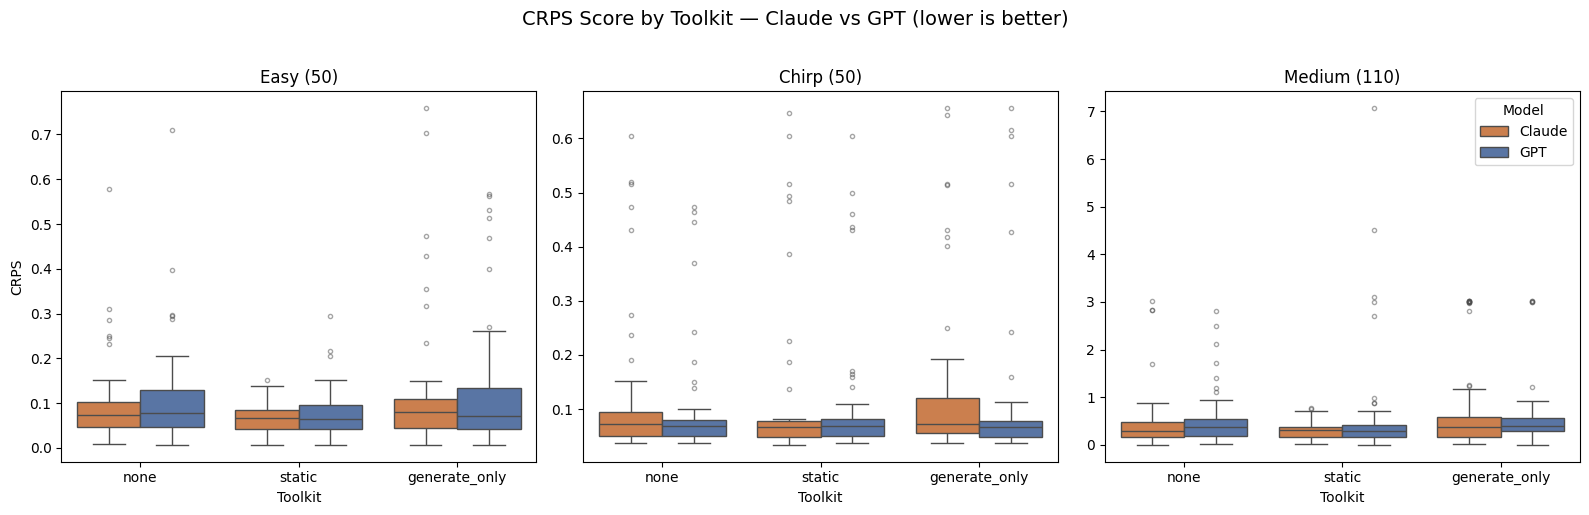

Saved: plot_crps_boxplot_claude_vs_gpt.png


In [6]:
DATASET_LABELS = {"easy_50": "Easy (50)", "chirp_50": "Chirp (50)", "medium_110": "Medium (110)"}
PALETTE = {"Claude": "#e07b39", "GPT": "#4c72b0"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("CRPS Score by Toolkit — Claude vs GPT (lower is better)", fontsize=14, y=1.02)

for ax, ds in zip(axes, DATASET_ORDER):
    subset = all_samples[all_samples["dataset"] == ds]
    sns.boxplot(
        data=subset, x="toolkit", y="crps", hue="model",
        palette=PALETTE, order=TOOLKIT_ORDER, ax=ax,
        showfliers=True, flierprops=dict(marker="o", markersize=3, alpha=0.5),
    )
    ax.set_title(DATASET_LABELS[ds], fontsize=12)
    ax.set_xlabel("Toolkit")
    ax.set_ylabel("CRPS" if ax == axes[0] else "")
    if ax != axes[-1]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Model", loc="upper right")

plt.tight_layout()
plt.savefig("plot_crps_boxplot_claude_vs_gpt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_crps_boxplot_claude_vs_gpt.png")

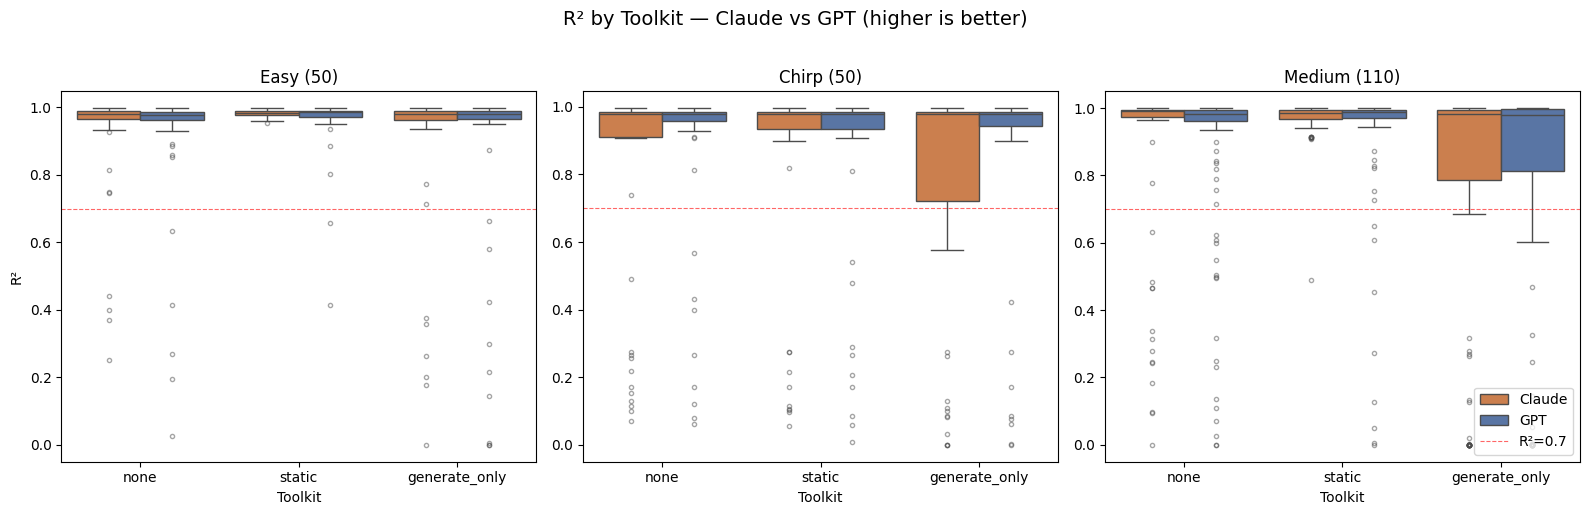

Saved: plot_r2_boxplot_claude_vs_gpt.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("R² by Toolkit — Claude vs GPT (higher is better)", fontsize=14, y=1.02)

for ax, ds in zip(axes, DATASET_ORDER):
    subset = all_samples[all_samples["dataset"] == ds]
    sns.boxplot(
        data=subset, x="toolkit", y="r2", hue="model",
        palette=PALETTE, order=TOOLKIT_ORDER, ax=ax,
        showfliers=True, flierprops=dict(marker="o", markersize=3, alpha=0.5),
    )
    # Add R²=0.7 reference line
    ax.axhline(0.7, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="R²=0.7")
    ax.set_title(DATASET_LABELS[ds], fontsize=12)
    ax.set_xlabel("Toolkit")
    ax.set_ylabel("R²" if ax == axes[0] else "")
    if ax != axes[-1]:
        ax.get_legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="", loc="lower right")

plt.tight_layout()
plt.savefig("plot_r2_boxplot_claude_vs_gpt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_r2_boxplot_claude_vs_gpt.png")